In [ ]:
!nvidia-smi

Mon Apr 13 09:03:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="mhEXVsJStID9JBbkWZXx")
project = rf.workspace("praktikum-1ldhd").project("kendaraan-vcabq")
version = project.version(1)
dataset = version.download("yolov9")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Kendaraan-1 in yolov9:: 100%|██████████| 649/649 [00:00<00:00, 9264.37it/s]


In [ ]:
# Ultralytics
from ultralytics import YOLO
model = YOLO("yolov9c.pt")
model.info()

YOLOv9c summary: 358 layers, 25,590,912 parameters, 0 gradients, 104.0 GFLOPs


(358, 25590912, 0, 104.02268160000003)

In [ ]:
aa

In [ ]:
model.train(
    data="/content/Kendaraan-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Kendaraan-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

RuntimeError: Dataset '/content/Kendaraan-1/data.yaml' error ❌ '/content/Kendaraan-1/data.yaml' does not exist

In [ ]:
!zip -r fajar-runs.zip runs/

  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/val_batch0_labels.jpg (deflated 6%)
  adding: runs/detect/train/args.yaml (deflated 53%)
  adding: runs/detect/train/train_batch1171.jpg (deflated 6%)
  adding: runs/detect/train/results.csv (deflated 62%)
  adding: runs/detect/train/BoxF1_curve.png (deflated 16%)
  adding: runs/detect/train/confusion_matrix.png (deflated 37%)
  adding: runs/detect/train/train_batch1170.jpg (deflated 7%)
  adding: runs/detect/train/train_batch2.jpg (deflated 2%)
  adding: runs/detect/train/weights/ (stored 0%)
  adding: runs/detect/train/weights/last.pt (deflated 8%)
  adding: runs/detect/train/weights/best.pt (deflated 8%)
  adding: runs/detect/train/BoxP_curve.png (deflated 19%)
  adding: runs/detect/train/train_batch1172.jpg (deflated 5%)
  adding: runs/detect/train/confusion_matrix_normalized.png (deflated 36%)
  adding: runs/detect/train/train_batch0.jpg (deflated 2%)

In [ ]:
import yaml

with open('/content/Kendaraan-1/yolov9/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

if 'names' in data:
    print("Classes:", data['names'])
else:
    print("Class names not found in the YAML file.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Kendaraan-1/data.yaml'


image 1/1 /content/sample.png: 640x608 1 Mobil, 61.4ms
Speed: 6.1ms preprocess, 61.4ms inference, 35.9ms postprocess per image at shape (1, 3, 640, 608)


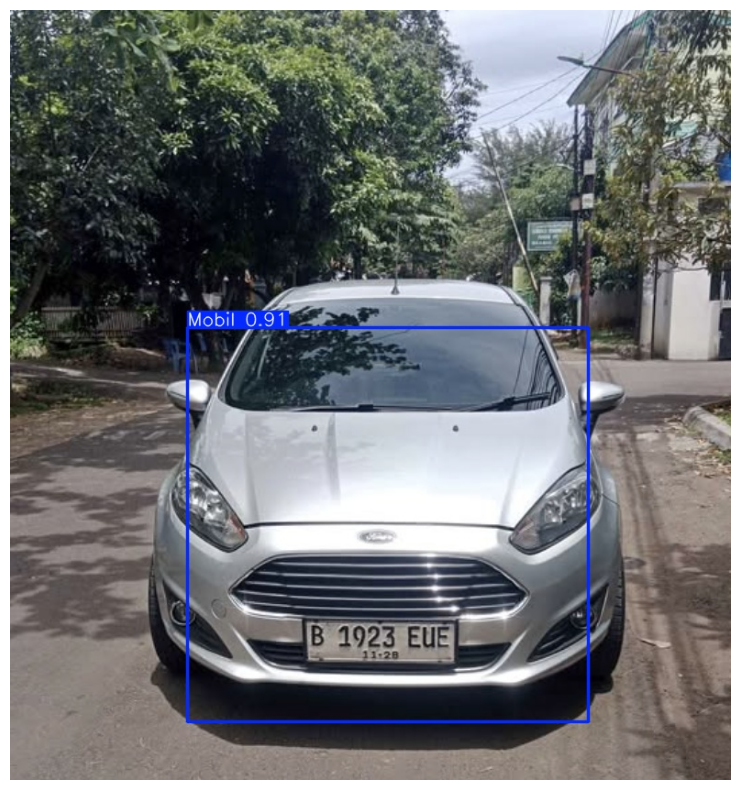

In [ ]:
from ultralytics import YOLO
import cv2, matplotlib.pyplot as plt

# Memuat model hasil pelatihan
model = YOLO('/content/best.pt')

# Melakukan deteksi pada gambar baru
image_path = '/content/sample.png'
results = model(image_path)

# Save the detected image and then display it
saved_image_path = '/content/detected_sample.jpg'
results[0].save(filename=saved_image_path)

# Display the saved image using matplotlib
img = plt.imread(saved_image_path)
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
!pip install pytesseract

In [ ]:
!apt-get install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
import cv2
import numpy as np
import imutils
import sys
import pytesseract
import os

# Konfigurasi path Tesseract for Colab
pytesseract.pytesseract.tesseract_cmd = r"/usr/bin/tesseract"

def detect_plate(image_path):
    # 1. Load Image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Gagal membaca gambar {image_path}")
        return

    # 2. Preprocessing Deteksi
    frame = imutils.resize(img, width=1200)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 13, 15, 15)

    edged = cv2.Canny(gray, 30, 200)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    candidates = []
    for mask in [edged, thresh]:
        cnts = cv2.findContours(mask.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cnts = imutils.grab_contours(cnts)

        for c in cnts:
            area = cv2.contourArea(c)
            if area < 600: continue

            x, y, w, h = cv2.boundingRect(c)
            ar = w / float(h)

            if 2.0 <= ar <= 5.5:
                is_lower = y > (gray.shape[0] * 0.45)
                rect_area = w * h
                rectangularity = area / float(rect_area)
                ar_penalty = np.exp(-4.0 * abs(ar - 3.3))
                score = (rectangularity ** 2) * ar_penalty * (2.0 if is_lower else 1.0)
                candidates.append({'cnt': c, 'area': area, 'ar': ar, 'rect': rectangularity, 'score': score})

    if candidates:
        candidates = sorted(candidates, key=lambda x: x['score'], reverse=True)
        best_candidate = candidates[0]
        for cand in candidates[:5]:
            if cand['rect'] > 0.75:
                best_candidate = cand
                break
        best_cnt = best_candidate['cnt']
    else:
        print(f"Gagal mendeteksi plat nomor pada {image_path}.")
        return

    # 3. Warp Perspective
    rect_min = cv2.minAreaRect(best_cnt)
    box = cv2.boxPoints(rect_min).astype(int)
    rect = np.zeros((4, 2), dtype="float32")
    s = box.sum(axis=1)
    rect[0], rect[2] = box[np.argmin(s)], box[np.argmax(s)]
    diff = np.diff(box, axis=1)
    rect[1], rect[3] = box[np.argmin(diff)], box[np.argmax(diff)]

    (tl, tr, br, bl) = rect
    maxWidth = max(int(np.linalg.norm(br - bl)), int(np.linalg.norm(tr - tl)))
    maxHeight = max(int(np.linalg.norm(tr - br)), int(np.linalg.norm(tl - bl)))
    dst = np.array([[0,0], [maxWidth-1,0], [maxWidth-1,maxHeight-1], [0,maxHeight-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(frame, M, (maxWidth, maxHeight))

    # 4. OCR Preprocessing (UNSHARP MASK & OTSU)
    plate_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    plate_gray = clahe.apply(plate_gray)
    plate_gray = cv2.bilateralFilter(plate_gray, 9, 75, 75)

    # Crop Borders ketat
    h_s, w_s = plate_gray.shape
    # 12% top, 23% bottom, 4% sides
    trim_top, trim_bot, trim_side = int(h_s * 0.12), int(h_s * 0.77), int(w_s * 0.04)
    plate_gray = plate_gray[trim_top:trim_bot, trim_side:w_s-trim_side]

    # Penajaman (Unsharp Mask)
    # Membuat tepi karakter lebih tegas agar tesseract bisa membedakan 4/6 dan V/U
    blurred = cv2.GaussianBlur(plate_gray, (0, 0), 3)
    plate_gray = cv2.addWeighted(plate_gray, 1.5, blurred, -0.5, 0)

    # Rescale Moderat
    plate_gray = cv2.resize(plate_gray, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    # Otsu Thresholding (SOLID karakter)
    _, plate_thresh = cv2.threshold(plate_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Padding putih luas
    plate_thresh = cv2.copyMakeBorder(plate_thresh, 50, 50, 50, 50, cv2.BORDER_CONSTANT, value=255)

    debug_name = f"ocr_debug_{os.path.basename(image_path).split('.')[0]}.png"
    cv2.imwrite(debug_name, plate_thresh)

    # 5. Tesseract OCR
    whitelist = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 "
    config = f'--oem 3 --psm 6 -c tessedit_char_whitelist="{whitelist}"'
    raw_text = pytesseract.image_to_string(plate_thresh, config=config)

    text = "".join([c for c in raw_text if c.isalnum() or c == " "]).strip().upper()
    text = " ".join(text.split())
    if len(text) > 4 and text[0] in ['I', '1', '|'] and text[1] == ' ':
        text = text[2:].strip()

    print("-" * 30)
    print(f"FILE: {image_path} -> RESULT: {text}")
    print("-" * 30)

if __name__ == "__main__":
    for s in ["/content/sample.png"]:
        detect_plate(s)


------------------------------
FILE: /content/sample.png -> RESULT: B 1923 EUE
------------------------------


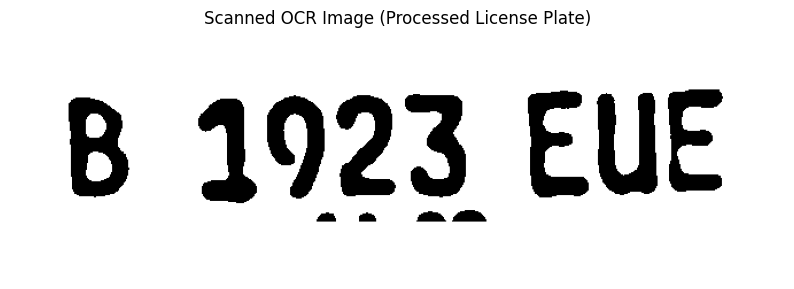

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Path to the debug image saved by the detect_plate function
debug_image_path = '/content/ocr_debug_sample.png'

# Read the image
img_debug = cv2.imread(debug_image_path)

# Convert BGR to RGB for matplotlib display
img_debug_rgb = cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10, 5))
plt.imshow(img_debug_rgb)
plt.title('Scanned OCR Image (Processed License Plate)')
plt.axis('off')
plt.show()

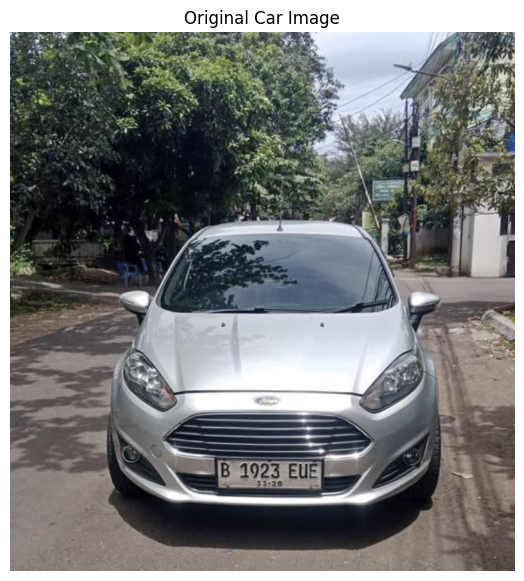

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Path to the original car image
original_image_path = '/content/sample.png'

# Read the image
img_original = cv2.imread(original_image_path)

# Convert BGR to RGB for matplotlib display
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(10, 7))
plt.imshow(img_original_rgb)
plt.title('Original Car Image')
plt.axis('off')
plt.show()